---
## 1. Setup and Import Libraries

In [ ]:
# Install scikit-learn
!pip install -q scikit-learn

print("scikit-learn installed!")

✓ scikit-learn installed!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
# ============================================
# KEEP-ALIVE SCRIPT (Works even if tab inactive)
# ============================================

from IPython.display import display, Javascript
import threading
import time

def keep_alive():
    """Keeps session alive even if browser tab is inactive"""
    while True:
        try:
            display(Javascript('console.log("Session active: " + new Date().toLocaleTimeString())'))
            time.sleep(300)  # Every 5 minutes
        except:
            break

# Start keep-alive in background
keep_alive_thread = threading.Thread(target=keep_alive, daemon=True)
keep_alive_thread.start()

print("✓ Keep-alive script running!")
print("✓ This works even if you switch browser tabs")

✓ Keep-alive script running!
✓ This works even if you switch browser tabs


<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import os

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print("✓ Libraries imported successfully!")

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✓ Libraries imported successfully!


---
## 2. Load Preprocessed Data from Phase 2

In [ ]:
# Load preprocessed data from Google Drive
import numpy as np

print("Loading preprocessed data from Google Drive...")

# Define the path to your Google Drive folder
data_path = "/content/drive/MyDrive/dataforproject/"

# Load the files
x_train = np.load(data_path + 'x_train_normalized.npy')
y_train = np.load(data_path + 'y_train_onehot.npy')
x_test = np.load(data_path + 'x_test_normalized.npy')
y_test = np.load(data_path + 'y_test_onehot.npy')

print(f"\n✓ Data loaded successfully!")
print(f"Training set: {x_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Test set: {x_test.shape}")
print(f"Test labels: {y_test.shape}")

Loading preprocessed data from Google Drive...

✓ Data loaded successfully!
Training set: (50000, 32, 32, 3)
Training labels: (50000, 10)
Test set: (10000, 32, 32, 3)
Test labels: (10000, 10)


---
## 3. Create Train/Validation Split

In [ ]:
# Split training data into train and validation (80/20 split)
from sklearn.model_selection import train_test_split

x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y_train, axis=1)  # Maintain class balance
)

print(f"Training set: {x_train_final.shape}")
print(f"Validation set: {x_val.shape}")
print(f"Test set: {x_test.shape}")

Training set: (40000, 32, 32, 3)
Validation set: (10000, 32, 32, 3)
Test set: (10000, 32, 32, 3)


---
## 4. Data Augmentation Setup

In [ ]:
# Data augmentation (applied during training only)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

print("✓ Data augmentation pipeline created")
print("Augmentations: Horizontal flip, Rotation (±10%), Zoom (±10%)")

✓ Data augmentation pipeline created
Augmentations: Horizontal flip, Rotation (±10%), Zoom (±10%)


---
## 5. Build EfficientNet-B0 Model

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


def swish(x):
    """Swish activation function (x * sigmoid(x))"""
    return x * tf.nn.sigmoid(x)


def squeeze_excitation_block(inputs, filters, se_ratio=0.25, name=None):
    # Squeeze
    se = layers.GlobalAveragePooling2D(name=f'{name}_se_squeeze')(inputs)
    se = layers.Reshape((1, 1, filters), name=f'{name}_se_reshape')(se)

    # Excitation
    num_reduced_filters = max(1, int(filters * se_ratio))
    se = layers.Conv2D(num_reduced_filters, 1, activation='relu',
                       padding='same', use_bias=True, name=f'{name}_se_reduce')(se)
    se = layers.Conv2D(filters, 1, activation='sigmoid',
                       padding='same', use_bias=True, name=f'{name}_se_expand')(se)

    # Scale
    x = layers.Multiply(name=f'{name}_se_excite')([inputs, se])
    return x


def mbconv_block(inputs, input_filters, output_filters, expand_ratio,
                 kernel_size, stride, se_ratio=0.25, name=None):


    x = inputs
    filters = input_filters * expand_ratio

    # 1. Expansion phase
    if expand_ratio != 1:
        x = layers.Conv2D(filters, 1, padding='same', use_bias=False,
                         name=f'{name}_expand_conv')(x)
        x = layers.BatchNormalization(name=f'{name}_expand_bn')(x)
        x = layers.Activation(swish, name=f'{name}_expand_activation')(x)

    # 2. Depthwise convolution
    if stride == 2:
        x = layers.ZeroPadding2D(padding=((0, 1), (0, 1)),
                                name=f'{name}_dwconv_pad')(x)
        conv_pad = 'valid'
    else:
        conv_pad = 'same'

    x = layers.DepthwiseConv2D(kernel_size, strides=stride, padding=conv_pad,
                               use_bias=False, name=f'{name}_dwconv')(x)
    x = layers.BatchNormalization(name=f'{name}_bn')(x)
    x = layers.Activation(swish, name=f'{name}_activation')(x)

    # 3. Squeeze-and-Excitation
    x = squeeze_excitation_block(x, filters, se_ratio, name=name)

    # 4. Projection phase
    x = layers.Conv2D(output_filters, 1, padding='same', use_bias=False,
                     name=f'{name}_project_conv')(x)
    x = layers.BatchNormalization(name=f'{name}_project_bn')(x)

    # 5. Skip connection (if dimensions match)
    if stride == 1 and input_filters == output_filters:
        x = layers.Add(name=f'{name}_add')([inputs, x])

    return x


def build_efficientnet_b0(include_top=False, weights='imagenet',
                          input_tensor=None, input_shape=None,
                          pooling='avg', classes=1000):

    # Determine input
    if input_tensor is None:
        if input_shape is None:
            input_shape = (224, 224, 3)
        img_input = layers.Input(shape=input_shape)
    else:
        if not keras.backend.is_keras_tensor(input_tensor):
            img_input = layers.Input(tensor=input_tensor, shape=input_shape)
        else:
            img_input = input_tensor

    x = img_input

    # Stem
    x = layers.ZeroPadding2D(padding=((0, 1), (0, 1)), name='stem_conv_pad')(x)
    x = layers.Conv2D(32, 3, strides=2, padding='valid', use_bias=False,
                     name='stem_conv')(x)
    x = layers.BatchNormalization(name='stem_bn')(x)
    x = layers.Activation(swish, name='stem_activation')(x)

    # MBConv Blocks (16 total across 7 stages)
    # Format: (input_filters, output_filters, expand_ratio, kernel, stride, repeats)
    blocks_args = [
        (32, 16, 1, 3, 1, 1),    # Stage 1
        (16, 24, 6, 3, 2, 2),    # Stage 2
        (24, 40, 6, 5, 2, 2),    # Stage 3
        (40, 80, 6, 3, 2, 3),    # Stage 4
        (80, 112, 6, 5, 1, 3),   # Stage 5
        (112, 192, 6, 5, 2, 4),  # Stage 6
        (192, 320, 6, 3, 1, 1),  # Stage 7
    ]

    for stage_idx, (in_f, out_f, exp, k, s, repeats) in enumerate(blocks_args, 1):
        for repeat_idx in range(repeats):
            stride = s if repeat_idx == 0 else 1
            input_filters = in_f if repeat_idx == 0 else out_f
            block_name = f'block{stage_idx}{chr(ord("a") + repeat_idx)}'

            x = mbconv_block(x, input_filters, out_f, exp, k, stride,
                           se_ratio=0.25, name=block_name)

    # Head
    x = layers.Conv2D(1280, 1, padding='same', use_bias=False, name='top_conv')(x)
    x = layers.BatchNormalization(name='top_bn')(x)
    x = layers.Activation(swish, name='top_activation')(x)

    # Pooling
    if include_top:
        x = layers.GlobalAveragePooling2D(name='avg_pool')(x)
        x = layers.Dropout(0.2, name='top_dropout')(x)
        x = layers.Dense(classes, activation='softmax', name='predictions')(x)
    else:
        if pooling == 'avg':
            x = layers.GlobalAveragePooling2D(name='avg_pool')(x)
        elif pooling == 'max':
            x = layers.GlobalMaxPooling2D(name='max_pool')(x)

    # Create model
    if input_tensor is not None:
        inputs = keras.utils.get_source_inputs(input_tensor)
    else:
        inputs = img_input

    model = keras.Model(inputs, x, name='efficientnetb0')

    # Load ImageNet weights
    if weights == 'imagenet':
        if include_top:
            weights_url = 'https://storage.googleapis.com/keras-applications/efficientnetb0.h5'
            weights_path = keras.utils.get_file('efficientnetb0.h5', weights_url,
                                               cache_subdir='models')
        else:
            weights_url = 'https://storage.googleapis.com/keras-applications/efficientnetb0_notop.h5'
            weights_path = keras.utils.get_file('efficientnetb0_notop.h5', weights_url,
                                               cache_subdir='models')
        model.load_weights(weights_path)

    return model

In [ ]:
def build_efficientnet_model(input_shape=(32, 32, 3), num_classes=10):

    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Resizing(224, 224)(x)

    # Use OUR custom implementation (defined above)
    base_model = build_efficientnet_b0(
        include_top=False,
        weights='imagenet',  # Loads ImageNet weights into OUR architecture
        input_tensor=x,
        pooling='avg'
    )

    base_model.trainable = False

    x = base_model.output
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs, outputs, name='EfficientNetB0_CIFAR10')

    return model, base_model

# Build the model
print("\nBuilding EfficientNet-B0 model...")
print("Using CUSTOM implementation ")
model, base_model = build_efficientnet_model()

print("\n" + "="*60)
print("MODEL ARCHITECTURE")
print("="*60)
model.summary()

# Count parameters
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")

Building EfficientNet-B0 model...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

MODEL ARCHITECTURE


Model: "EfficientNetB0_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 32, 32, 3) │          0 │ input_layer[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 224, 224,  │          0 │ data_augmentatio… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ resizing[0][0]    │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


Total parameters: 4,062,381
Trainable parameters: 12,810
Non-trainable parameters: 4,049,571


---
## 6. Compile Model

In [ ]:
# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_accuracy')]
)

print("✓ Model compiled")
print("\nTraining Configuration:")
print("  - Optimizer: Adam (lr=0.001)")
print("  - Loss: Categorical Crossentropy")
print("  - Metrics: Accuracy, Top-5 Accuracy")

✓ Model compiled

Training Configuration:
  - Optimizer: Adam (lr=0.001)
  - Loss: Categorical Crossentropy
  - Metrics: Accuracy, Top-5 Accuracy


---
## 7. Setup Training Callbacks

In [ ]:
# Create callbacks for training

# 1. Early stopping - stop if validation loss doesn't improve
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# 2. Reduce learning rate when validation loss plateaus
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# 3. Model checkpoint - save EVERY epoch to Google Drive ⭐ MODIFIED
checkpoint = keras.callbacks.ModelCheckpoint(
    '/content/drive/MyDrive/dataforproject/checkpoint_epoch_{epoch:02d}.h5',
    save_freq='epoch',  # Save every epoch (not just best)
    verbose=1
)

# 4. Best model checkpoint - save best model to Google Drive ⭐ NEW
best_checkpoint = keras.callbacks.ModelCheckpoint(
    '/content/drive/MyDrive/dataforproject/efficientnet_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

callbacks = [early_stopping, reduce_lr, checkpoint, best_checkpoint]

print("✓ Training callbacks configured")
print("✓ Checkpoints will save to Google Drive every epoch")
print("✓ Best model will also be saved")

✓ Training callbacks configured
✓ Checkpoints will save to Google Drive every epoch
✓ Best model will also be saved


---
## 8. Train Model (Phase 1: Feature Extraction)

In [ ]:
# Phase 1: Train only the classification head (base model frozen)
print("="*60)
print("PHASE 1: TRAINING CLASSIFICATION HEAD")
print("="*60)
print("Base model frozen - only training new Dense layers")
print()

EPOCHS_PHASE1 = 20  # Train for 20 epochs
BATCH_SIZE = 32

history_phase1 = model.fit(
    x_train_final, y_train_final,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_PHASE1,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Phase 1 training complete!")

PHASE 1: TRAINING CLASSIFICATION HEAD
Base model frozen - only training new Dense layers

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.0988 - loss: 2.3348 - top5_accuracy: 0.5027
Epoch 1: saving model to /content/drive/MyDrive/dataforproject/checkpoint_epoch_01.h5



Epoch 1: finished saving model to /content/drive/MyDrive/dataforproject/checkpoint_epoch_01.h5

Epoch 1: val_accuracy improved from None to 0.10000, saving model to /content/drive/MyDrive/dataforproject/efficientnet_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/dataforproject/efficientnet_best.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 147s 106ms/step - accuracy: 0.1011 - loss: 2.3334 - top5_accuracy: 0.4981 - val_accuracy: 0.1000 - val_loss: 2.3355 - val_top5_accuracy: 0.5000 - learning_rate: 0.0010
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.0972 - loss: 2.3331 - top5_accuracy: 0.5005
Epoch 2: saving model to /content/drive/MyDrive/dataforproject/checkpoint_epoch_02.h5



Epoch 2: finished saving model to /content/drive/MyDrive/dataforproject/checkpoint_epoch_02.h5

Epoch 2: val_accuracy did not improve from 0.10000
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 115s 92ms/step - accuracy: 0.0990 - loss: 2.3315 - top5_accuracy: 0.4984 - val_accuracy: 0.1000 - val_loss: 2.3358 - val_top5_accuracy: 0.5000 - learning_rate: 0.0010
Epoch 3/20
  79/1250 ━━━━━━━━━━━━━━━━━━━━ 1:25 73ms/step - accuracy: 0.0875 - loss: 2.3390 - top5_accuracy: 0.5040

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.1029 - loss: 2.3181 - top5_accuracy: 0.4996
Epoch 18: saving model to /content/drive/MyDrive/dataforproject/checkpoint_epoch_18.h5



Epoch 18: finished saving model to /content/drive/MyDrive/dataforproject/checkpoint_epoch_18.h5

Epoch 18: val_accuracy did not improve from 0.10160
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 114s 91ms/step - accuracy: 0.1035 - loss: 2.3172 - top5_accuracy: 0.5017 - val_accuracy: 0.1000 - val_loss: 2.3148 - val_top5_accuracy: 0.5000 - learning_rate: 5.0000e-04
Epoch 19/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.1032 - loss: 2.3182 - top5_accuracy: 0.4979
Epoch 19: saving model to /content/drive/MyDrive/dataforproject/checkpoint_epoch_19.h5



Epoch 19: finished saving model to /content/drive/MyDrive/dataforproject/checkpoint_epoch_19.h5

Epoch 19: val_accuracy did not improve from 0.10160
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 115s 92ms/step - accuracy: 0.1023 - loss: 2.3174 - top5_accuracy: 0.5018 - val_accuracy: 0.1000 - val_loss: 2.3145 - val_top5_accuracy: 0.5000 - learning_rate: 5.0000e-04
Epoch 20/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.1004 - loss: 2.3177 - top5_accuracy: 0.5052
Epoch 20: saving model to /content/drive/MyDrive/dataforproject/checkpoint_epoch_20.h5



Epoch 20: finished saving model to /content/drive/MyDrive/dataforproject/checkpoint_epoch_20.h5

Epoch 20: val_accuracy did not improve from 0.10160
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 115s 92ms/step - accuracy: 0.1006 - loss: 2.3172 - top5_accuracy: 0.5056 - val_accuracy: 0.1000 - val_loss: 2.3147 - val_top5_accuracy: 0.5000 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 16.

✓ Phase 1 training complete!


---
## 9. Fine-Tune Model (Phase 2: Unfreeze Base Model)

In [ ]:
# Phase 2: Fine-tune the entire model
print("="*60)
print("PHASE 2: FINE-TUNING ENTIRE MODEL")
print("="*60)
print("Unfreezing base model for fine-tuning...")

# Unfreeze base model
base_model.trainable = True

# Recompile with lower learning rate for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),  # Lower LR
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_accuracy')]
)

trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable parameters: {trainable_params:,}")
print()

EPOCHS_PHASE2 = 30  # Fine-tune for 30 epochs

history_phase2 = model.fit(
    x_train_final, y_train_final,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_PHASE2,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    initial_epoch=history_phase1.epoch[-1],  # Continue from phase 1
    verbose=1
)

print("\n✓ Phase 2 fine-tuning complete!")

PHASE 2: FINE-TUNING ENTIRE MODEL
Unfreezing base model for fine-tuning...
Trainable parameters: 4,020,358

Epoch 20/30


<IPython.core.display.Javascript object>

 863/1250 ━━━━━━━━━━━━━━━━━━━━ 2:11 339ms/step - accuracy: 0.5376 - loss: 1.3077 - top5_accuracy: 0.8976

<IPython.core.display.Javascript object>

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.5933 - loss: 1.1572 - top5_accuracy: 0.9182
Epoch 20: saving model to /content/drive/MyDrive/dataforproject/checkpoint_epoch_20.h5


...

<IPython.core.display.Javascript object>

 881/1250 ━━━━━━━━━━━━━━━━━━━━ 2:05 340ms/step - accuracy: 0.9820 - loss: 0.0533 - top5_accuracy: 0.9999

<IPython.core.display.Javascript object>

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.9823 - loss: 0.0525 - top5_accuracy: 0.9999
Epoch 30: saving model to /content/drive/MyDrive/dataforproject/checkpoint_epoch_30.h5



Epoch 30: finished saving model to /content/drive/MyDrive/dataforproject/checkpoint_epoch_30.h5

Epoch 30: val_accuracy did not improve from 0.73780
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 449s 359ms/step - accuracy: 0.9833 - loss: 0.0498 - top5_accuracy: 0.9999 - val_accuracy: 0.4751 - val_loss: 1.8916 - val_top5_accuracy: 0.8939 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 27.

✓ Phase 2 fine-tuning complete!


---
## 10. Evaluate Model on Test Set

In [ ]:
# Evaluate on test set
print("="*60)
print("FINAL EVALUATION ON TEST SET")
print("="*60)

test_loss, test_acc, test_top5_acc = model.evaluate(x_test, y_test, verbose=1)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Top-5 Accuracy: {test_top5_acc*100:.2f}%")

FINAL EVALUATION ON TEST SET
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 74ms/step - accuracy: 0.7397 - loss: 0.9343 - top5_accuracy: 0.9776

Test Loss: 0.9343
Test Accuracy: 73.97%
Test Top-5 Accuracy: 97.76%


---
## 11. Plot Training History

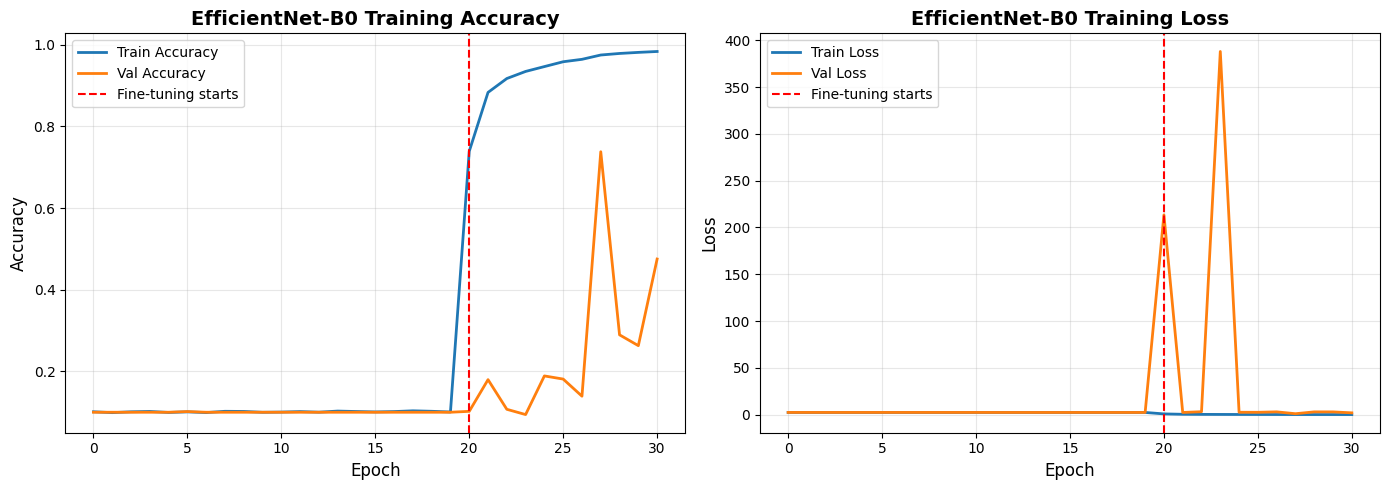

✓ Training history plot saved as 'efficientnet_training_history.png'


In [ ]:
# Combine history from both phases
history_combined = {
    'accuracy': history_phase1.history['accuracy'] + history_phase2.history['accuracy'],
    'val_accuracy': history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy'],
    'loss': history_phase1.history['loss'] + history_phase2.history['loss'],
    'val_loss': history_phase1.history['val_loss'] + history_phase2.history['val_loss']
}

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history_combined['accuracy'], label='Train Accuracy', linewidth=2)
ax1.plot(history_combined['val_accuracy'], label='Val Accuracy', linewidth=2)
ax1.axvline(x=EPOCHS_PHASE1, color='red', linestyle='--', label='Fine-tuning starts')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('EfficientNet-B0 Training Accuracy', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Loss plot
ax2.plot(history_combined['loss'], label='Train Loss', linewidth=2)
ax2.plot(history_combined['val_loss'], label='Val Loss', linewidth=2)
ax2.axvline(x=EPOCHS_PHASE1, color='red', linestyle='--', label='Fine-tuning starts')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('EfficientNet-B0 Training Loss', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('efficientnet_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training history plot saved as 'efficientnet_training_history.png'")

---
## 12. Make Predictions on Sample Images

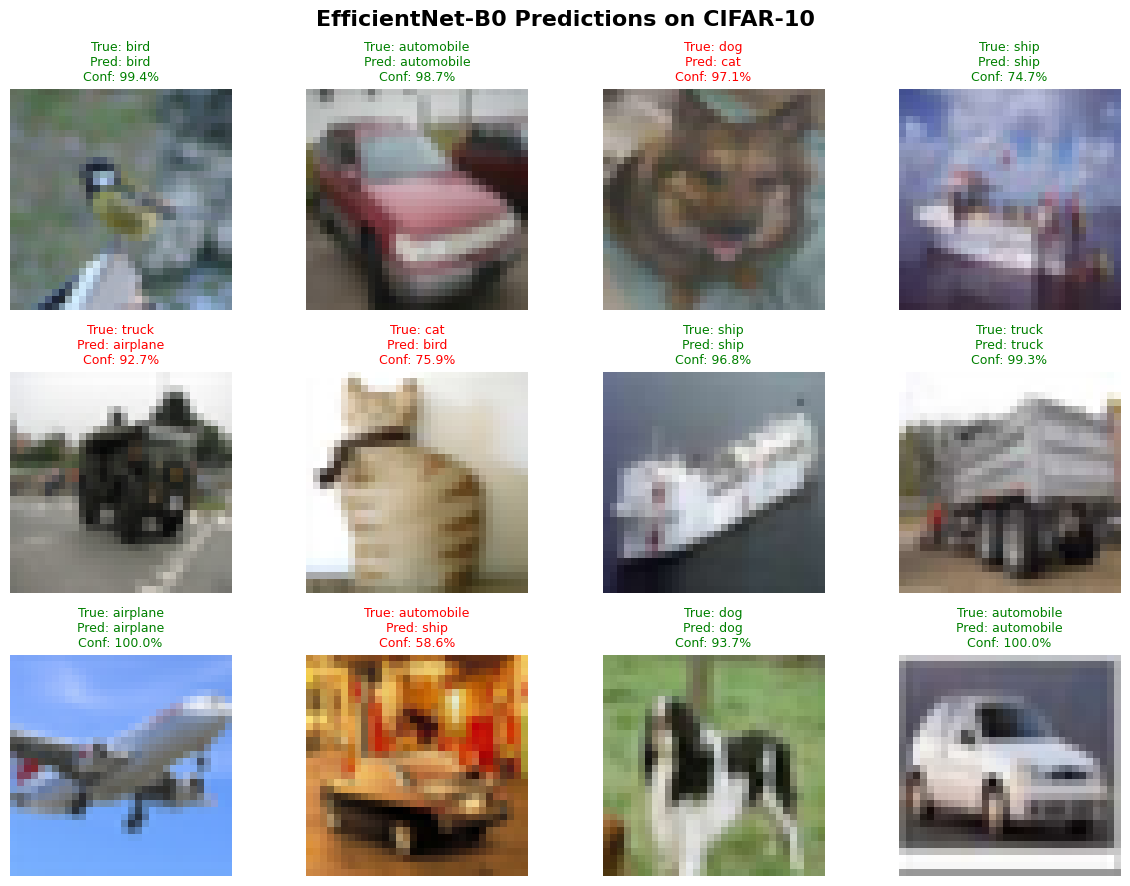

✓ Predictions visualization saved as 'efficientnet_predictions.png'

Sample accuracy: 8/12 = 66.7%


In [ ]:
# Make predictions on some test images
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Select 12 random test images
indices = np.random.choice(len(x_test), 12, replace=False)
sample_images = x_test[indices]
sample_labels = y_test[indices]

# Make predictions
predictions = model.predict(sample_images, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(sample_labels, axis=1)

# Visualize predictions
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
fig.suptitle('EfficientNet-B0 Predictions on CIFAR-10', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i])

    # Color code: green if correct, red if wrong
    color = 'green' if predicted_classes[i] == true_classes[i] else 'red'

    ax.set_title(
        f"True: {class_names[true_classes[i]]}\nPred: {class_names[predicted_classes[i]]}\nConf: {predictions[i][predicted_classes[i]]*100:.1f}%",
        fontsize=9,
        color=color
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('efficientnet_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Predictions visualization saved as 'efficientnet_predictions.png'")

# Calculate accuracy on these samples
correct = np.sum(predicted_classes == true_classes)
print(f"\nSample accuracy: {correct}/12 = {correct/12*100:.1f}%")

---
## 13. Confusion Matrix

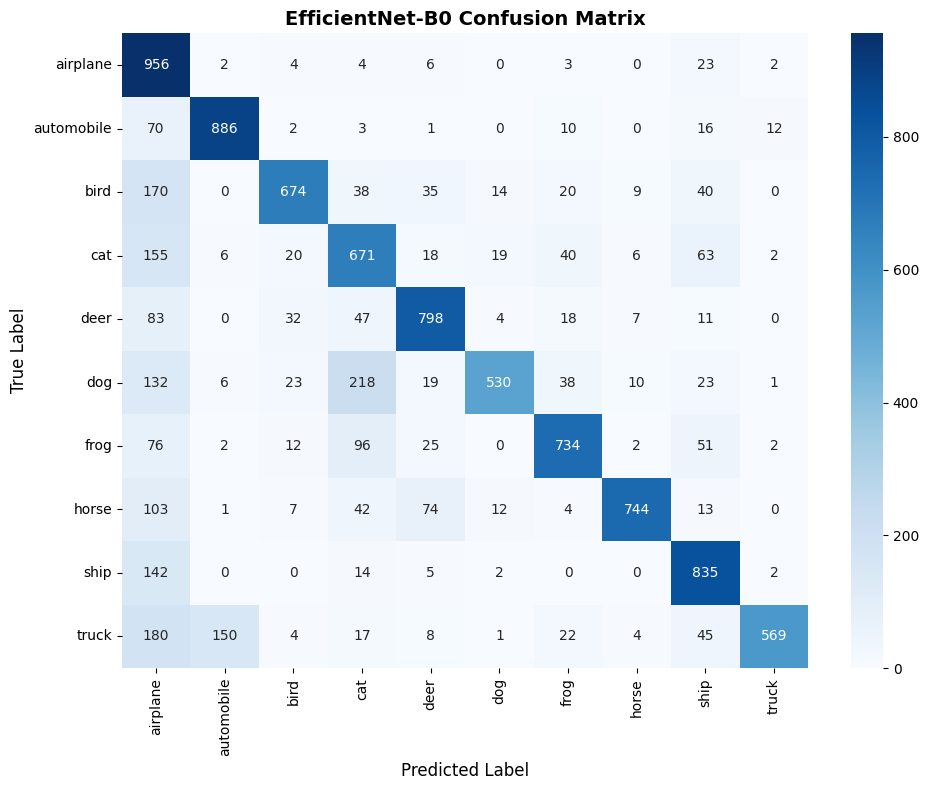

✓ Confusion matrix saved as 'efficientnet_confusion_matrix.png'

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    airplane       0.46      0.96      0.62      1000
  automobile       0.84      0.89      0.86      1000
        bird       0.87      0.67      0.76      1000
         cat       0.58      0.67      0.62      1000
        deer       0.81      0.80      0.80      1000
         dog       0.91      0.53      0.67      1000
        frog       0.83      0.73      0.78      1000
       horse       0.95      0.74      0.84      1000
        ship       0.75      0.83      0.79      1000
       truck       0.96      0.57      0.72      1000

    accuracy                           0.74     10000
   macro avg       0.80      0.74      0.75     10000
weighted avg       0.80      0.74      0.75     10000



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions for entire test set
y_pred = model.predict(x_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('EfficientNet-B0 Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('efficientnet_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix saved as 'efficientnet_confusion_matrix.png'")

# Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

---
## 14. Save Final Model

In [ ]:
# Save the final model
model.save('efficientnet_cifar10_final.h5')
print("✓ Final model saved as 'efficientnet_cifar10_final.h5'")

# Save training history
np.save('training_history.npy', history_combined)
print("✓ Training history saved as 'training_history.npy'")

✓ Final model saved as 'efficientnet_cifar10_final.h5'
✓ Training history saved as 'training_history.npy'


In [ ]:
# Save all results to Google Drive
import shutil

output_path = "/content/drive/MyDrive/dataforproject/"

print("Saving results to Google Drive...")

# Save model files
shutil.copy('efficientnet_best.h5', output_path + 'efficientnet_best.h5')
shutil.copy('efficientnet_cifar10_final.h5', output_path + 'efficientnet_cifar10_final.h5')

# Save plots
shutil.copy('efficientnet_training_history.png', output_path + 'efficientnet_training_history.png')
shutil.copy('efficientnet_predictions.png', output_path + 'efficientnet_predictions.png')
shutil.copy('efficientnet_confusion_matrix.png', output_path + 'efficientnet_confusion_matrix.png')

# Save training history
shutil.copy('training_history.npy', output_path + 'training_history.npy')

print("✓ All files saved to Google Drive!")
print(f"Location: {output_path}")

Saving results to Google Drive...


FileNotFoundError: [Errno 2] No such file or directory: 'efficientnet_best.h5'